## Libraries

In [1]:
%pip install  shap


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Functions

### Get traffic data

In [3]:
def get_traffic_data():
    # Direct link to the raw CSV
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
    
    # Load data (pandas handles the .gz compression automatically)
    df = pd.read_csv(url)
    
    # 1. Convert timestamp to datetime and extract time-based features
    # These are critical "hidden" sensors for traffic
    df['date_time'] = pd.to_datetime(df['date_time'])
    df['hour'] = df['date_time'].dt.hour
    df['day_of_week'] = df['date_time'].dt.dayofweek
    
    # 2. Binary Target: 1 if traffic_volume > 4500 (Heavy), else 0
    # 4500 is a standard threshold for "congested" on this specific road
    df['is_heavy'] = (df['traffic_volume'] > 4500).astype(int)
    
    # 3. Clean up Categorical Weather (One-Hot Encoding)
    # This turns 'Rain', 'Snow', 'Clouds' into transparent 0/1 columns
    df = pd.get_dummies(df, columns=['weather_main'], prefix='w')
    
    # 4. Final Selection of Features for XAI
    features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week'] + \
               [c for c in df.columns if c.startswith('w_')]
    
    df_final = df[features + ['is_heavy']]
    return df_final, features


### Traffic Data Pipeline

In [4]:
from sklearn.preprocessing import MinMaxScaler

class TrafficDataPipeline:
    def __init__(self, window_size=24):
        self.window_size = window_size
        self.scaler = MinMaxScaler()
        self.feature_names = None

    def fit_transform(self, df):
        # Separate Features and Target
        y_raw = df['is_heavy'].values
        X_raw = df.drop(columns=['is_heavy'])
        self.feature_names = X_raw.columns.tolist()

        # Scale the numerical data (0 to 1)
        X_scaled = self.scaler.fit_transform(X_raw)

        # Create the 3D Windows (The 'Chopping')
        X_3d, y_3d = [], []
        for i in range(len(X_scaled) - self.window_size):
            X_3d.append(X_scaled[i : i + self.window_size])
            y_3d.append(y_raw[i + self.window_size])
            
        return np.array(X_3d), np.array(y_3d)

    def inverse_transform_features(self, scaled_window):
        """Useful for XAI to show real values (Celsius, Hours) instead of 0-1"""
        return self.scaler.inverse_transform(scaled_window)

### Build XAI Traffic Model

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_xai_traffic_model(input_shape):
    """
    input_shape: (24, num_features) 
    24 time steps (hours) and your encoded features.
    """
    model = models.Sequential([
        # THE INPUT: The 24-hour 'block'
        layers.Input(shape=input_shape),

        # FEATURE EXTRACTION: Detecting Local Patterns
        # Layer 1: 64 filters to catch basic 'shapes' in the data
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        
        # Layer 2: 128 filters to find more complex relationships 
        # (e.g., 'Cold Temp' occurring at '8 AM')
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        
        # THE XAI BRIDGE: Global Average Pooling (GAP)
        # This collapses the 24 hours into 128 average 'scores'.
        # Vital for Grad-CAM because it keeps the feature maps interpretable.
        layers.GlobalAveragePooling1D(),

        # DECISION HEAD: The final reasoning
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3), # Helps the model generalize (not just memorize)
        layers.Dense(1, activation='sigmoid') # Binary Output: 0 (Light) or 1 (Heavy)
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## Getting Data

In [6]:
df_traffic, traffic_features = get_traffic_data()
print(f"Dataset Loaded: {df_traffic.shape[0]} rows (hours).")
print(df_traffic.head())

Dataset Loaded: 48204 rows (hours).
     temp  rain_1h  snow_1h  clouds_all  hour  day_of_week  w_Clear  w_Clouds  \
0  288.28      0.0      0.0          40     9            1    False      True   
1  289.36      0.0      0.0          75    10            1    False      True   
2  289.58      0.0      0.0          90    11            1    False      True   
3  290.13      0.0      0.0          90    12            1    False      True   
4  291.14      0.0      0.0          75    13            1    False      True   

   w_Drizzle  w_Fog  w_Haze  w_Mist  w_Rain  w_Smoke  w_Snow  w_Squall  \
0      False  False   False   False   False    False   False     False   
1      False  False   False   False   False    False   False     False   
2      False  False   False   False   False    False   False     False   
3      False  False   False   False   False    False   False     False   
4      False  False   False   False   False    False   False     False   

   w_Thunderstorm  is_heavy  
0 

## Transforming Data

In [7]:
pipeline = TrafficDataPipeline(window_size=24)
X_final, y_final = pipeline.fit_transform(df_traffic)

print(f"Pipeline complete! Input shape: {X_final.shape}")
print(f"Target shape: {y_final.shape}")

Pipeline complete! Input shape: (48180, 24, 17)
Target shape: (48180,)


## Training the model

In [8]:
input_shape = (X_final.shape[1], X_final.shape[2]) 
model = build_xai_traffic_model(input_shape)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,121 (145.00 KB)

 Trainable params: 36,737 (143.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [9]:
from sklearn.model_selection import train_test_split

# 1. Create the 'Final Exam' (Test Set)
# We take 20% of the data and lock it in a vault.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_final, y_final, test_size=0.2, shuffle=False
)

# 2. Create the 'Practice Quiz' (Validation Set)
# From the remaining 80%, we take another 20% for validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, shuffle=False
)

# 3. Train and Validate
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val), # The Practice Quiz
    verbose=1
)

# 4. The Final Exam Score
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Final Exam (Test) Accuracy: {test_acc*100:.2f}%")

Epoch 1/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7622 - loss: 0.4681 - val_accuracy: 0.8731 - val_loss: 0.2985
Epoch 2/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8666 - loss: 0.3080 - val_accuracy: 0.9045 - val_loss: 0.2398
Epoch 3/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8758 - loss: 0.2867 - val_accuracy: 0.8637 - val_loss: 0.3504
Epoch 4/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8822 - loss: 0.2731 - val_accuracy: 0.8944 - val_loss: 0.2497
Epoch 5/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8889 - loss: 0.2592 - val_accuracy: 0.9149 - val_loss: 0.2281
Epoch 6/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8912 - loss: 0.2511 - val_accuracy: 0.8849 - val_loss: 0.2702
Epoch 7/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8976 - loss: 0.2385 - val_accuracy: 0.9062 - val_loss: 0.2286
Epoch 8/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9031 - loss: 0.2287 - val_accuracy: 0.

## Model Performance Evaluation

302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step


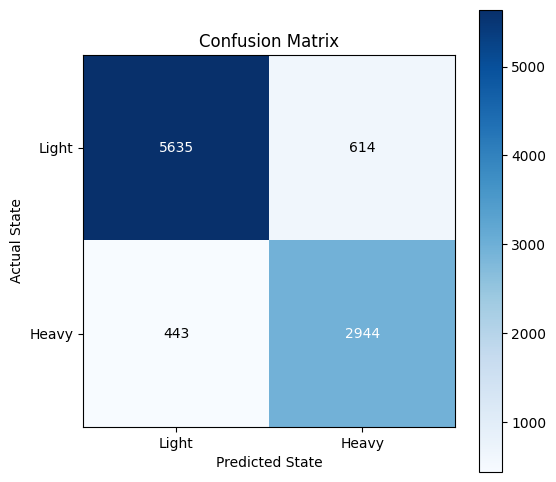

In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report


# Get model predictions
y_pred_probs = model.predict(X_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

# --- CONFUSION MATRIX (Manual Heatmap) ---
cm = confusion_matrix(y_test, y_pred)
classes = ['Light', 'Heavy']

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Set labels and ticks
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes, yticklabels=classes,
       title='Confusion Matrix',
       ylabel='Actual State',
       xlabel='Predicted State')

# Loop over data dimensions and create text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.show()

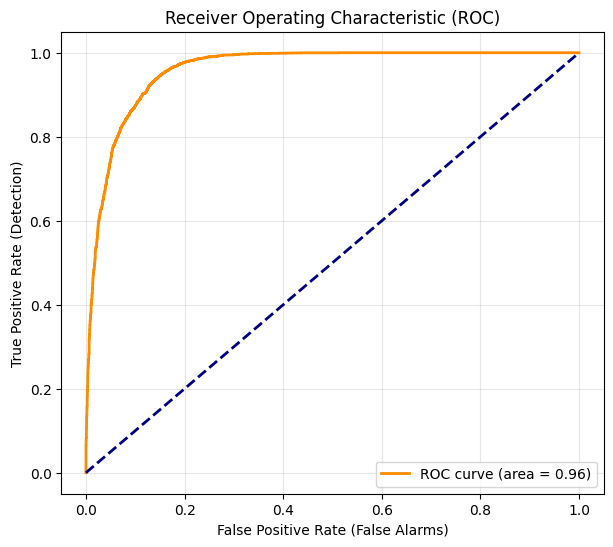


--- Classification Report ---
              precision    recall  f1-score   support

       Light       0.93      0.90      0.91      6249
       Heavy       0.83      0.87      0.85      3387

    accuracy                           0.89      9636
   macro avg       0.88      0.89      0.88      9636
weighted avg       0.89      0.89      0.89      9636



In [11]:
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Detection)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 2. Detailed Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=classes))

## XAI Methods

### SHAPS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Selected instance 250:
Model prediction: 0.999
Actual label: 1
3D shape: (1, 24, 17)
Instance 2D shape: (1, 408)
Background 2D shape: (100, 408)
Computing SHAP values (this may take a moment)...


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values 3D shape: (1, 24, 17)


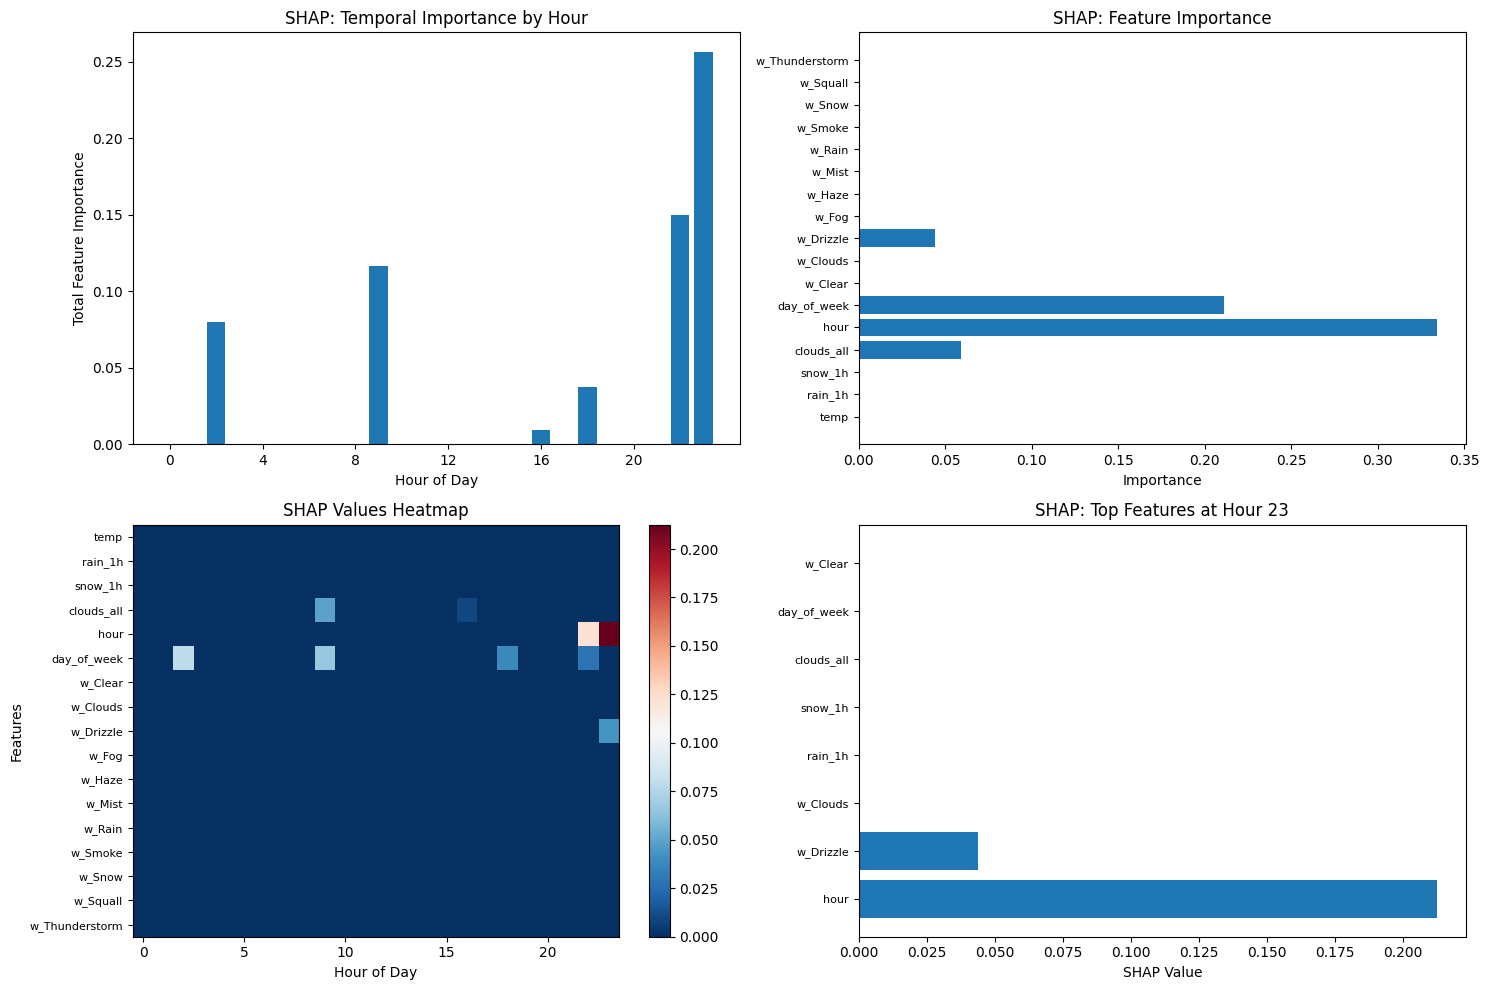


--- Shap Analysis Summary ---
Most important hour: 23 (importance: 0.256)
Most important feature: hour (importance: 0.334)
Prediction confidence: 0.999 (Heavy traffic)
Actual label: Heavy traffic


In [12]:
import shap

# ShaTS: SHAP for Time Series Analysis
# This approach uses temporal aggregation to make SHAP work with time series data

# 1. SELECT A SAMPLE INSTANCE
sample_idx = 250
instance_3d = X_test[sample_idx:sample_idx+1]  # Shape: (1, 24, 17)
actual_prediction = model.predict(instance_3d)[0][0]
actual_label = y_test[sample_idx]

print(f"Selected instance {sample_idx}:")
print(f"Model prediction: {actual_prediction:.3f}")
print(f"Actual label: {actual_label}")
print(f"3D shape: {instance_3d.shape}")

# 2. CREATE A WRAPPER FUNCTION FOR THE MODEL
# SHAP needs a function that accepts 2D input, but our model expects 3D
def model_predict_wrapper(X_2d):
    """
    Wrapper to convert 2D SHAP input back to 3D for the model
    X_2d shape: (n_samples, n_features) where n_features = 24*17 = 408
    """
    # Reshape from 2D back to 3D: (n_samples, 24, 17)
    n_samples = X_2d.shape[0]
    X_3d = X_2d.reshape(n_samples, 24, 17)
    # Get predictions and return as 1D array for SHAP
    predictions = model.predict(X_3d, verbose=0)
    return predictions.ravel()

# 3. PREPARE DATA FOR SHAP
# Convert instance from 3D to 2D: (1, 24, 17) -> (1, 408)
instance_2d = instance_3d.reshape(1, -1)

# Create background data (sample from training set)
# Take a small representative sample and flatten it
background_indices = np.random.choice(len(X_train), size=100, replace=False)
background_3d = X_train[background_indices]
background_2d = background_3d.reshape(background_3d.shape[0], -1)

print(f"Instance 2D shape: {instance_2d.shape}")
print(f"Background 2D shape: {background_2d.shape}")

# 4. CREATE SHAP EXPLAINER
explainer = shap.KernelExplainer(model_predict_wrapper, background_2d)

# Calculate SHAP values
print("Computing SHAP values (this may take a moment)...")
shap_values = explainer.shap_values(instance_2d, nsamples=100)

# 5. RESHAPE SHAP VALUES BACK TO TIME SERIES FORMAT
# From (1, 408) back to (1, 24, 17)
shap_values_3d = shap_values.reshape(1, 24, 17)

print(f"SHAP values 3D shape: {shap_values_3d.shape}")

# 6. TEMPORAL AGGREGATION FOR VISUALIZATION
# Sum importance across all features for each time step
temporal_importance = np.abs(shap_values_3d[0]).sum(axis=1)  # Shape: (24,)

# Feature importance (sum across all time steps)
feature_importance = np.abs(shap_values_3d[0]).sum(axis=0)  # Shape: (17,)

# 7. VISUALIZATIONS

# Plot 1: Temporal Importance (which hours matter most)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].bar(range(24), temporal_importance)
axes[0,0].set_title('SHAP: Temporal Importance by Hour')
axes[0,0].set_xlabel('Hour of Day')
axes[0,0].set_ylabel('Total Feature Importance')
axes[0,0].set_xticks(range(0, 24, 4))

# Plot 2: Feature Importance (which features matter most)
feature_names = pipeline.feature_names
axes[0,1].barh(range(len(feature_names)), feature_importance)
axes[0,1].set_title('SHAP: Feature Importance')
axes[0,1].set_xlabel('Importance')
axes[0,1].set_yticks(range(len(feature_names)))
axes[0,1].set_yticklabels(feature_names, fontsize=8)

# Plot 3: Heatmap of SHAP values over time and features
im = axes[1,0].imshow(shap_values_3d[0].T, aspect='auto', cmap='RdBu_r')
axes[1,0].set_title('SHAP Values Heatmap')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Features')
axes[1,0].set_yticks(range(len(feature_names)))
axes[1,0].set_yticklabels(feature_names, fontsize=8)
plt.colorbar(im, ax=axes[1,0])

# Plot 4: Top contributing features at peak hour
peak_hour = np.argmax(temporal_importance)
peak_hour_values = shap_values_3d[0, peak_hour, :]
sorted_indices = np.argsort(np.abs(peak_hour_values))[::-1][:8]

axes[1,1].barh(range(8), peak_hour_values[sorted_indices])
axes[1,1].set_title(f'SHAP: Top Features at Hour {peak_hour}')
axes[1,1].set_xlabel('SHAP Value')
axes[1,1].set_yticks(range(8))
axes[1,1].set_yticklabels([feature_names[i] for i in sorted_indices], fontsize=8)

plt.tight_layout()
plt.show()

# 8. SUMMARY STATISTICS
print("\n--- Shap Analysis Summary ---")
print(f"Most important hour: {np.argmax(temporal_importance)} (importance: {temporal_importance.max():.3f})")
print(f"Most important feature: {feature_names[np.argmax(feature_importance)]} (importance: {feature_importance.max():.3f})")
print(f"Prediction confidence: {actual_prediction:.3f} ({'Heavy' if actual_prediction > 0.5 else 'Light'} traffic)")
print(f"Actual label: {'Heavy' if actual_label == 1 else 'Light'} traffic")

### ShaTS

Calculating ShaTS values... (Flattened logic)


  0%|          | 0/1 [00:00<?, ?it/s]

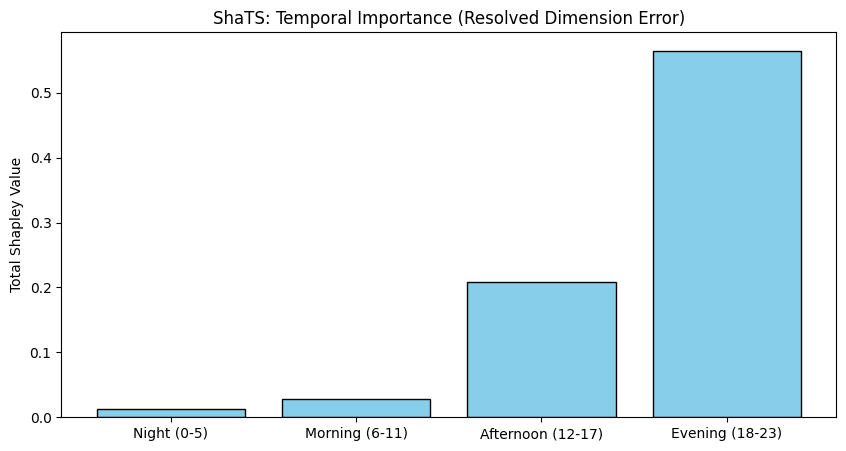

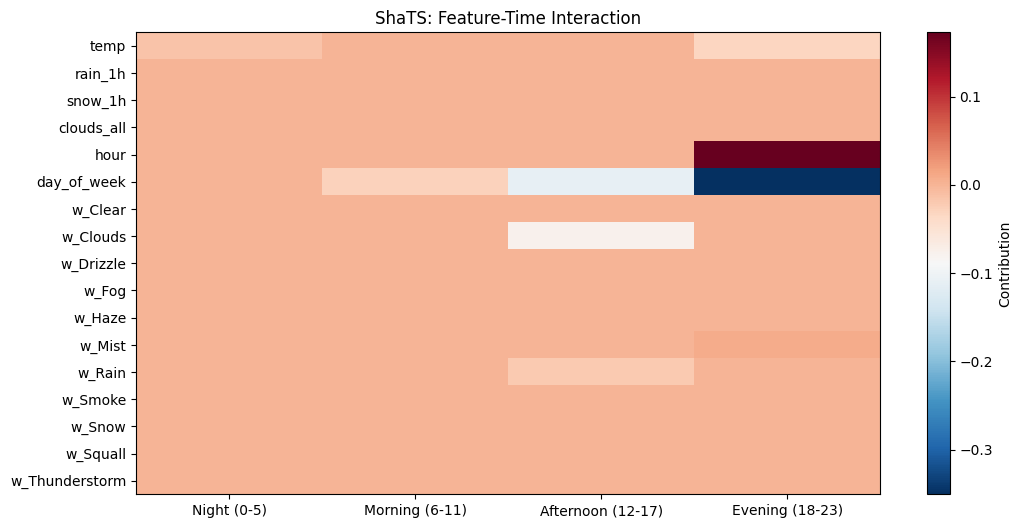

In [31]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. PREPARE THE DATA
# Flatten the 4 groups into a single 1D vector (4 blocks * 17 features = 68 features)
n_features = X_train.shape[2]
background_raw = X_train[np.random.choice(X_train.shape[0], 50, replace=False)]
background_grouped = background_raw.reshape(50, 4, 6, n_features).mean(axis=2)
# FLATTEN for SHAP: (50, 68)
background_flat = background_grouped.reshape(50, -1) 

# 2. THE UPDATED SHATS WRAPPER
def shats_predict_flattened(flat_input):
    """
    Takes flat input (N, 68), reshapes to (N, 4, 17), 
    then expands to (N, 24, 17) for the CNN.
    """
    # Step A: Back to Grouped 3D (N, 4, 17)
    grouped = flat_input.reshape(flat_input.shape[0], 4, n_features)
    # Step B: Expand to Full 24h (N, 24, 17)
    reconstructed = np.repeat(grouped, 6, axis=1)
    return model.predict(reconstructed, verbose=0).ravel()

# 3. INITIALIZE EXPLAINER WITH FLAT DATA
explainer = shap.KernelExplainer(shats_predict_flattened, background_flat)

# 4. EXPLAIN AN INSTANCE (Index 200)
instance_3d = X_test[300:301]
instance_grouped = instance_3d.reshape(1, 4, 6, n_features).mean(axis=2)
# FLATTEN the instance for the explainer: (1, 68)
instance_flat = instance_grouped.reshape(1, -1)

print("Calculating ShaTS values... (Flattened logic)")
shap_values = explainer.shap_values(instance_flat, nsamples=100)

# 5. RESHAPE RESULTS BACK FOR VISUALIZATION
# We turn the 68 values back into (4 blocks, 17 features)
shap_matrix = shap_values[0].reshape(4, n_features)

# --- VISUALIZATION ---
group_names = ['Night (0-5)', 'Morning (6-11)', 'Afternoon (12-17)', 'Evening (18-23)']
block_importance = np.abs(shap_matrix).sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(group_names, block_importance, color='skyblue', edgecolor='black')
plt.title("ShaTS: Temporal Importance (Resolved Dimension Error)")
plt.ylabel("Total Shapley Value")
plt.show()

# Feature x Block Heatmap
plt.figure(figsize=(12, 6))
plt.imshow(shap_matrix.T, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Contribution')
plt.xticks(range(4), group_names)
plt.yticks(range(len(pipeline.feature_names)), pipeline.feature_names)
plt.title("ShaTS: Feature-Time Interaction")
plt.show()

### Grad-CAM

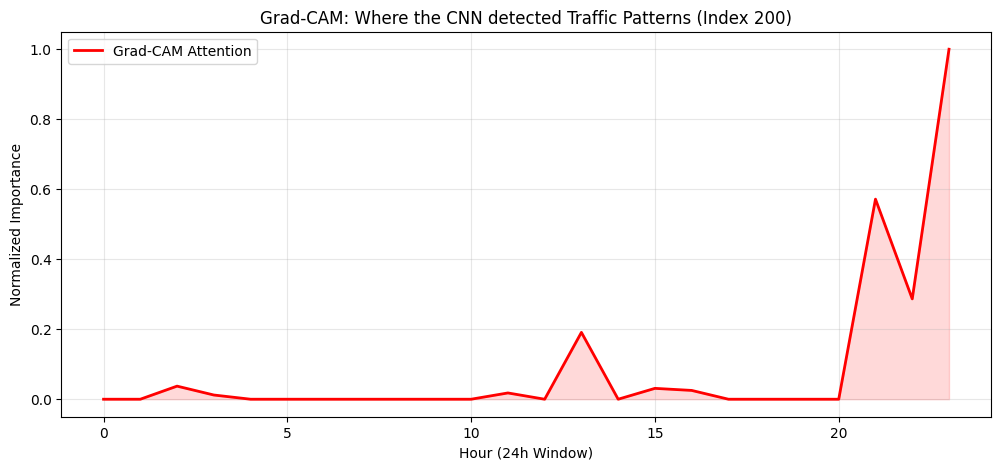

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

def get_gradcam_1d(model, data_instance, class_idx=0):
    """
    Final robust version for Sequential 1D-CNN models.
    Uses explicit shape definition to avoid 'input_shape' AttributeErrors.
    """
    # 1. Manually define the input shape from your instance
    # data_instance shape is (1, 24, 17), so we need (24, 17)
    input_shape = data_instance.shape[1:] 
    
    # 2. Identify the last Conv1D layer
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv1D):
            last_conv_layer_name = layer.name
            break
            
    if not last_conv_layer_name:
        raise ValueError("Could not find a Conv1D layer.")

    # 3. RECONSTRUCT THE GRAPH (The "Functional Bridge")
    img_input = tf.keras.Input(shape=input_shape)
    x = img_input
    target_conv_output = None
    
    # We loop through all layers to rebuild the symbolic connections
    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            target_conv_output = x
            
    # Create the sub-model that Keras can now differentiate
    grad_model = tf.keras.models.Model(img_input, [target_conv_output, x])

    # 4. GRADIENT CALCULATION
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(data_instance)
        # Binary classification usually uses a single output neuron
        loss = predictions[:, class_idx] if predictions.shape[-1] > 1 else predictions[:, 0]

    # 5. POOLING AND WEIGHTING
    grads = tape.gradient(loss, conv_outputs)
    # Average the gradients across the temporal dimension
    weights = tf.reduce_mean(grads, axis=(0, 1))

    # Weight the original conv output by these importance weights
    output = conv_outputs[0] 
    heatmap = output @ weights[..., tf.newaxis]
    
    # 6. POST-PROCESSING
    heatmap = tf.squeeze(heatmap)
    # ReLU: We only care about hours that POSITIVELY contributed to "Heavy Traffic"
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    
    return heatmap.numpy()

# --- Execution ---
# Ensure your X_test[sample_idx] is reshaped to (1, 24, 17)
instance = X_test[sample_idx:sample_idx+1]

# Calculate the heatmap
gc_heatmap = get_gradcam_1d(model, instance)

# --- Visualization ---
plt.figure(figsize=(12, 5))
plt.plot(range(24), gc_heatmap, color='red', linewidth=2, label='Grad-CAM Attention')
plt.fill_between(range(24), gc_heatmap, color='red', alpha=0.15)
plt.title(f"Grad-CAM: Where the CNN detected Traffic Patterns (Index {sample_idx})")
plt.xlabel("Hour (24h Window)")
plt.ylabel("Normalized Importance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()